# Linear Discriminant Analysis 

## 1. Problem Setup

Assume we have a dataset:

$$
\{(\mathbf{x}_1, y_1), (\mathbf{x}_2, y_2), \dots, (\mathbf{x}_N, y_N)\}
$$

where:

- $\mathbf{x}_i \in \mathbb{R}^D$ is the feature vector  
- $y_i \in \{1, 2, \dots, K\}$ is the class label  

The goal is to classify each input into one of $K$ classes.

---

## 2. Class Priors

The prior probability of class $k$ is estimated as:

$$
\pi_k = \frac{N_k}{N}
$$

where $N_k$ is the number of samples in class $k$ and $N$ is the total number of samples.

---

## 3. Class Means

The mean vector for each class $k$ is:

$$
\boldsymbol{\mu}_k = \frac{1}{N_k} \sum_{i: y_i = k} \mathbf{x}_i
$$

---

## 4. Shared Covariance Matrix

LDA assumes all classes share the same covariance matrix. We compute the class-wise covariance matrices first:

$$
\Sigma_k = \sum_{i: y_i=k} (\mathbf{x}_i - \boldsymbol{\mu}_k)(\mathbf{x}_i - \boldsymbol{\mu}_k)^T
$$

Then combine them into the pooled covariance:

$$
\Sigma = \frac{1}{N} \sum_{k=1}^{K} \Sigma_k
$$

We also add a small **regularization term** for numerical stability:

$$
\Sigma \leftarrow \Sigma + \text{reg} \cdot I
$$

where $I$ is the $D \times D$ identity matrix.

---

## 5. Discriminant Function

For each class $k$, the discriminant function is linear in $\mathbf{x}$:

$$
\delta_k(\mathbf{x}) = \mathbf{x}^T \Sigma^{-1} \boldsymbol{\mu}_k - \frac{1}{2} \boldsymbol{\mu}_k^T \Sigma^{-1} \boldsymbol{\mu}_k + \log \pi_k
$$

- $\Sigma^{-1} \boldsymbol{\mu}_k$ is precomputed for efficiency  
- The second term is a scalar for each class  
- The last term incorporates class priors

---

## 6. Prediction Rule

The predicted class is the one with the largest discriminant score:

$$
\hat{y} = \arg\max_k \delta_k(\mathbf{x})
$$

---

## 7. Assumptions

- Each class is normally distributed with **same covariance**  
- Linear boundaries are optimal under Gaussian assumption  
- Works well when classes are linearly separable

---



In [1]:
class LDA:
    """
    Linear Discriminant Analysis (LDA) classifier.

    LDA assumes that each class is Gaussian distributed with a shared covariance matrix
    and estimates a linear decision boundary.

    Parameters
    ----------
    reg : float, default=1e-10
        Small regularization term added to the covariance matrix to ensure numerical stability.

    Attributes
    ----------
    pi_k : ndarray of shape (n_classes,)
        Estimated class prior probabilities.
    mu_k : ndarray of shape (n_classes, n_features)
        Estimated class means.
    sigma : ndarray of shape (n_features, n_features)
        Shared covariance matrix.
    classes : ndarray of shape (n_classes,)
        Unique class labels.
    """

    def __init__(self,reg=1e-10):
        self.reg = reg
        self.pi_k = None
        self.mu_k = None
        self.sigma = None
        self.classes = None

    def fit(self,X,y):
        """
        Fit the LDA model to the training data.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            Training feature matrix.
        y : ndarray of shape (n_samples,)
            Target labels.

        Returns
        -------
        self : object
            Fitted LDA instance.
        """

        # Identify unique classes and counts
        N,D = X.shape
        
        self.classes, N_k = np.unique(y,return_counts=1)
        num_classes = len(self.classes)

        # Estimate class priors
        self.pi_k = N_k/N

        # Estimate class means
        self.mu_k = np.array([X[y==k].mean(axis=0) for k in self.classes])

        # Compute class-specific covariance contributions  
        self.sigma = np.zeros((D,D,num_classes))

        for i,k in enumerate(self.classes):
            X_centered = X[y==k] - self.mu_k[i] # Center samples around class mean
            self.sigma[:,:,i] = X_centered.T @ X_centered
            
         
        # Compute shared covariance matrix (weighted average)
        self.sigma = np.sum(self.sigma, axis=2)/N

        # Add small regularization term for numerical stability
        self.sigma += self.reg * np.eye(D)

        return self


    def predict(self,X):
        """
        Predict class labels for input data X.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            Input feature matrix.

        Returns
        -------
        y_pred : ndarray of shape (n_samples,)
            Predicted class labels.
        """
        # Solve sigma^{-1} @ mu_k efficiently
        Sigma_inv_mu = solve(self.sigma, self.mu_k.T)    
        
        # Compute linear term: X @ sigma^{-1} @ mu_k
        linear = X @ Sigma_inv_mu                 

        # Compute quadratic term: 0.5 * mu_k.T @ sigma^{-1} @ mu_k
        quad = np.sum(self.mu_k * Sigma_inv_mu.T, axis=1)   

        # Compute scores for each class
        scores = linear - 0.5 * quad + np.log(self.pi_k + self.reg)

        # Return class with maximum score for each sample
        return self.classes[np.argmax(scores,axis=1)]       

### LDA — Effect of Covariance Assumption Violation

### 1. Problem Setup

We have a binary classification dataset:

$$
\{(\mathbf{x}_i, y_i)\}_{i=1}^{N}, \quad y_i \in \{0,1\}, \quad \mathbf{x}_i \in \mathbb{R}^2
$$

where each class is generated from a Gaussian distribution:

$$
\mathbf{x}_i | y_i = k \sim \mathcal{N}(\boldsymbol{\mu}_k, \Sigma_k)
$$

LDA assumes **all classes share the same covariance matrix**:

$$
\Sigma_0 = \Sigma_1 = \Sigma
$$

---

### 2. Datasets

We create two datasets:

1. **Proper LDA Dataset (No Violation)**

$$
\Sigma_0 = \Sigma_1 = 
\begin{bmatrix}
1 & 0.5 \\
0.5 & 1
\end{bmatrix}
$$

- Both classes share the same covariance.
- LDA assumption holds.

2. **Violated LDA Dataset**

$$
\Sigma_0 = 
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}, 
\quad 
\Sigma_1 = 
\begin{bmatrix}
3 & 1.5 \\
1.5 & 1
\end{bmatrix}
$$

- Classes have **different covariance matrices**.
- LDA assumption is violated.

---

### 3. LDA Model

LDA estimates:

1. **Class prior probabilities**

$$
\pi_k = \frac{N_k}{N}
$$

2. **Class means**

$$
\boldsymbol{\mu}_k = \frac{1}{N_k} \sum_{i:y_i=k} \mathbf{x}_i
$$

3. **Shared covariance matrix**

$$
\Sigma = \frac{1}{N} \sum_{k=0}^{1} \sum_{i:y_i=k} (\mathbf{x}_i - \boldsymbol{\mu}_k)(\mathbf{x}_i - \boldsymbol{\mu}_k)^T + \text{reg} \cdot I
$$

Prediction for a new point $\mathbf{x}$:

$$
\hat{y} = \arg\max_k \Big[ \mathbf{x}^T \Sigma^{-1} \boldsymbol{\mu}_k - \frac{1}{2} \boldsymbol{\mu}_k^T \Sigma^{-1} \boldsymbol{\mu}_k + \log \pi_k \Big]
$$

---

### 4. Expected Behavior

- **Proper dataset (no violation):**
  - Estimated $\Sigma$ matches the true covariance.
  - Decision boundary is **linear and optimal**.
  - Accuracy is **high**.

- **Violated dataset:**
  - Estimated $\Sigma$ is a weighted average of $\Sigma_0$ and $\Sigma_1$.
  - LDA forces a **linear decision boundary**.
  - True optimal boundary is **quadratic (QDA)**.
  - Accuracy **drops**, misclassifications occur where class shapes differ.

---


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

# Generate datasets
def generate_data(N=100, violation=False):
    np.random.seed(42)
    mu0 = np.array([0,0])
    mu1 = np.array([3,0])
    
    if violation:
        Sigma0 = np.array([[1,0],[0,1]])
        Sigma1 = np.array([[3,1.5],[1.5,1]])
    else:
        Sigma0 = np.array([[1,0.5],[0.5,1]])
        Sigma1 = Sigma0.copy()
        
    X0 = np.random.multivariate_normal(mu0, Sigma0, N)
    X1 = np.random.multivariate_normal(mu1, Sigma1, N)
    X = np.vstack([X0, X1])
    y = np.array([0]*N + [1]*N)
    return X, y

datasets = {'Proper': generate_data(), 'Violated': generate_data(violation=True)}

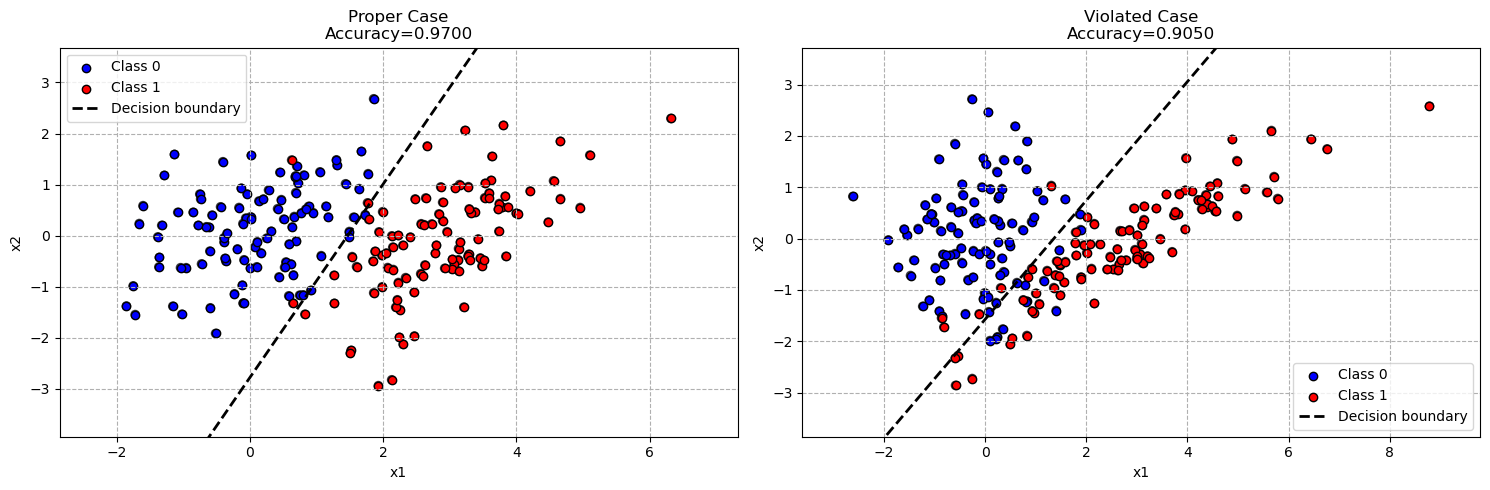

In [3]:
# Fit and Plot

plt.figure(figsize=(15,5))

for i,(name,(X,y)) in enumerate(datasets.items()):
    model = LDA(reg=1e-5)
    model.fit(X,y)
    y_pred = model.predict(X)
    acc = np.mean(y_pred==y)
    
    plt.subplot(1,2,i+1)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolor='k', alpha=0.7)
    
    plt.grid(True, linestyle='--', alpha=1)
    plt.xlim(X[:,0].min()-1, X[:,0].max()+1)
    plt.ylim(X[:,1].min()-1, X[:,1].max()+1)
    
    plt.scatter(X[y==0,0], X[y==0,1], color='blue', edgecolor='k', label='Class 0')
    plt.scatter(X[y==1,0], X[y==1,1], color='red', edgecolor='k', label='Class 1')

    # Decision boundary
    mu = model.mu_k
    Sigma_inv = np.linalg.inv(model.sigma)
    w = Sigma_inv @ (mu[1]-mu[0])
    b = 0.5 * (mu[1].T @ Sigma_inv @ mu[1] - mu[0].T @ Sigma_inv @ mu[0])

    
    x_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
    y_vals = (b - w[0]*x_vals)/w[1]
    
    plt.plot(x_vals, y_vals, 'k--', label='Decision boundary' , linewidth=2)
    
    plt.title(f"{name} Case\nAccuracy={acc:.4f}")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()

plt.tight_layout()
plt.show()


### 5. Conclusion

- LDA performs well **only if covariance matrices are equal**.
- Violation of the assumption introduces **bias** in the decision boundary.
- Quadratic Discriminant Analysis (QDA) would handle covariance differences correctly.
---